# Probing Practical Deliberation (PPD)

In [1]:
# start tracing server
import phoenix as px
px.launch_app()

/Users/ggbetz/git/practical-deliberation-llms/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


🌍 To view the Phoenix app in your browser, visit http://localhost:6006/
📖 For more information on how to use Phoenix, check out https://docs.arize.com/phoenix


In [2]:
# init tracing
from phoenix.otel import register

tracer_provider = register(
  project_name="default",
)

from openinference.instrumentation.langchain import LangChainInstrumentor

LangChainInstrumentor().instrument(tracer_provider=tracer_provider)

🔭 OpenTelemetry Tracing Details 🔭
|  Phoenix Project: default
|  Span Processor: SimpleSpanProcessor
|  Collector Endpoint: localhost:4317
|  Transport: gRPC
|  Transport Headers: {'user-agent': '****'}
|  
|  Using a default SpanProcessor. `add_span_processor` will overwrite this default.
|  
|  `register` has set this TracerProvider as the global OpenTelemetry default.
|  To disable this behavior, call `register` with `set_global_tracer_provider=False`.



In [3]:
import datasets
import dataclasses
from operator import itemgetter
import pandas as pd
import textwrap
from uuid import uuid4

from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import RunnableLambda, RunnablePassthrough
from langchain_openai import ChatOpenAI

import loguru

from practical_deliberation_llms.util import get_labelprobs_from_message


## Inference Client

In [4]:
# Setup inference client

model_kwargs={
    "model": "meta-llama/Llama-3.1-8B-Instruct",
    "base_url": "http://thages.philosophie.kit.edu:8080/v1",
    "api_key": "empty",
}

chat_model = ChatOpenAI(**model_kwargs)  # NOTE: nameing? > llm?


In [5]:
# test API
# See also: https://python.langchain.com/docs/concepts/lcel/
output_parser = StrOutputParser()
chain = (
    ChatPromptTemplate.from_messages([("user","Tell me a joke about {x}!")])
    | chat_model.bind(logprobs=True, top_logprobs=5, extra_body={"max_tokens": 5})
    | output_parser
    | {"x": RunnablePassthrough()}    
)
chain.name = "joke"
chain.invoke({"x":"kids"})

{'x': "Here's one:\n\nWhy"}

## _Daily Dilemmas_ Dataset

In [15]:
# load datset from hub and convert to pandas dataframe
ds = datasets.load_dataset("kellycyy/daily_dilemmas", "Dilemmas_with_values_aggregated")
df_dilemmas = pd.DataFrame(ds["test"])
df_dilemmas

,idx,dilemma_idx,basic_situation,dilemma_situation,action_type,action,negative_consequence,values_aggregated,topic,topic_group
0,0,55,taking initiative.,You're a project manager in a marketing firm. ...,to_do,Report the colleague,You report the colleague to your superior. The...,"['honesty', 'responsibility', 'accountability'...",11,workplace
1,1,55,taking initiative.,You're a project manager in a marketing firm. ...,not_to_do,Not report the colleague,You decide not to report the colleague. The mi...,"['avoidance of conflict', 'tolerance', 'self',...",11,workplace
2,2,107,missing your team's matches because you're inj...,You are a key player in your football team and...,to_do,Play the match,"You decide to play, pushing through the pain. ...","['courage', 'teamwork', 'responsibility', 'car...",26,issue_young_people
3,3,107,missing your team's matches because you're inj...,You are a key player in your football team and...,not_to_do,Sit out the match,You choose to prioritize your health and sit o...,"['self', 'resilience', 'responsibility', 'care...",26,issue_young_people
4,4,176,helping someone out when they want to find new...,You are a librarian and a frequent visitor ask...,to_do,Recommend controversial books,You recommend the controversial books. The vis...,['professional integrity'],44,event_daily_life
...,...,...,...,...,...,...,...,...,...,...
2715,2715,49950,feeling lonely and wanting someone in your life,You have been feeling increasingly lonely and ...,not_to_do,Not pursue a potential relationship with your ...,You choose not to act on the feelings. The lon...,"['selflessness', 'respect for friendship', 'tr...",35,issue_self_image_social
2716,2716,49959,giving someone free things.,A charity organization has received a generous...,to_do,Distribute the Clothes,The organization distributes the clothes. Howe...,"['integrity', 'dignity', 'honesty', 'justice']",15,business_organization
2717,2717,49959,giving someone free things.,A charity organization has received a generous...,not_to_do,Report to Police,The organization reports the matter to the pol...,"['honesty', 'justice', 'accountability', 'dign...",15,business_organization
2718,2718,49971,being a picky eater.,You're a picky eater and have been invited to ...,to_do,Eat the dish,You decide to respect the host and try the dis...,"['courage', 'adaptability', 'respect', 'unders...",40,event_special


In [16]:
# inspect df
# df_dilemmas.action_type.unique()
# >>> array(['to_do', 'not_to_do'], dtype=object)

# df_dilemmas.dilemma_idx.value_counts().unique()
# >>> array([2])

In [17]:
# in the original dataset, each dilemma is represented by two rows, we're collapsing them here

def collapse_dilemma(df: pd.DataFrame, dilemma_idx: int) -> dict:
    df_tmp = df[df.dilemma_idx == dilemma_idx].copy()
    assert len(df_tmp) == 2
    df_tmp.drop(columns=["idx"], inplace=True)
    data = {}
    for column in df_tmp.columns:
        if df_tmp[column].nunique() == 1:
            data[column] = df_tmp[column].values[0]
        else: 
            data[column] = df_tmp[column].values
    return data

df_dilemmas_consolidated = pd.DataFrame([collapse_dilemma(df_dilemmas, i) for i in df_dilemmas.dilemma_idx.unique()])
del df_dilemmas

In [18]:
#df_dilemmas_consolidated.head()

## Define Structure of Practical Problem and Decisions

In [19]:
# TODO: move this to python file

from dataclasses import dataclass

@dataclass
class PracticalProblem:
    decision_situation: str
    actions: list[str]
    labels: list[str] | None = None

    def __post_init__(self):
        if self.labels is None:
            self.labels = ["abcdefghijk"[i] for i in range(len(self.actions))]

    def reverse_order(self) -> "PracticalProblem":
        return PracticalProblem(
            decision_situation=self.decision_situation,
            actions=self.actions[::-1],
            labels=self.labels
        )

    @staticmethod
    def options_list(labels, actions, **kwargs) -> str:
        """Formats options as string for prompt"""
        assert len(labels) == len(actions), "labels and options must have same length"
        foptions = [
            f"({label}) {option}"
            for label, option in zip(labels, actions)
        ]
        return "\n".join(foptions)        
    


@dataclass
class Choice:
    label_probs: dict[str, float]
    label: str | None = None
    idx: int | None = None

    def __post_init__(self):
        assert self.label is None and self.idx is None, "label and idx must be None"
        self.label = max(self.label_probs.items(), key=itemgetter(1))[0]
        self.idx = list(self.label_probs.keys()).index(self.label)



In [20]:
# sanity checks
pp = PracticalProblem(
    decision_situation="A or B?",
    actions=["A", "B"],
)
pp_r = pp.reverse_order()
assert PracticalProblem.options_list(**dataclasses.asdict(pp)) == "(a) A\n(b) B"
assert PracticalProblem.options_list(**dataclasses.asdict(pp_r)) == "(a) B\n(b) A"
assert pp.decision_situation == pp_r.decision_situation
del pp, pp_r

c = Choice(
    label_probs={"A": 0.1, "B": 0.9}
)
assert c.label == "B"
del c


## Set up PPD DataFrame

In [21]:
MAX_SAMPLES = 100
SUBSET = "dd_baseline"

data = [
    {
        **dataclasses.asdict(PracticalProblem(decision_situation=r.dilemma_situation,actions=list(r.action))),
        "subset": SUBSET,
        "uid": str(uuid4()),
        "metadata": {"daily_dilemma_idx": r.dilemma_idx, "source": "daily_dilemmas"},
    }
    for _, r in df_dilemmas_consolidated.iterrows()
]

df_ppd = pd.DataFrame(data)
df_ppd = df_ppd[:MAX_SAMPLES]
del data

df_ppd.head()

,decision_situation,actions,labels,subset,uid,metadata
0,You're a project manager in a marketing firm. ...,"[Report the colleague, Not report the colleague]","[a, b]",dd_baseline,cb24d429-dc0d-4522-8fe2-ea01258262e2,"{'daily_dilemma_idx': 55, 'source': 'daily_dil..."
1,You are a key player in your football team and...,"[Play the match, Sit out the match]","[a, b]",dd_baseline,8f997659-c58f-45d2-aeb1-61762f27f5b7,"{'daily_dilemma_idx': 107, 'source': 'daily_di..."
2,You are a librarian and a frequent visitor ask...,"[Recommend controversial books, Do not recomme...","[a, b]",dd_baseline,8e588bd4-926c-40b6-9425-1be3ad79101b,"{'daily_dilemma_idx': 176, 'source': 'daily_di..."
3,You're on a picnic with friends and brought a ...,"[Giving food to the homeless person, Not givin...","[a, b]",dd_baseline,ef48653e-c746-43a5-88a5-fd5d8aa8a636,"{'daily_dilemma_idx': 257, 'source': 'daily_di..."
4,You've been living in a shared apartment for a...,"[Reading the journal, Not reading the journal]","[a, b]",dd_baseline,31937b43-d8f5-4243-8cfc-3893353c139b,"{'daily_dilemma_idx': 283, 'source': 'daily_di..."


## Deliberation **Operators**

In [45]:
make_decision_template = ChatPromptTemplate.from_messages([
    (
        "user",
        textwrap.dedent("""
        {decision_situation}
        What should you do?

        {options_list}

        Brief answer. No explanations.""").strip(" \n")
    )
])

remove_reason_template = ChatPromptTemplate.from_messages([
    (
        "user",
        textwrap.dedent("""
        Identify a reason in the following situation that speaks {valence} the action "{ref_action}". Then, remove the reason from the description of the situation. In doing so, avoid explicit valuations and stick to the original description as far as possible. Make sure to enclose your modified situation in tags '<situation>' and '</situation>', too.
        <situation>
        {decision_situation}
        </situation>""").strip(" \n")
    )
])

add_reason_template = ChatPromptTemplate.from_messages([
    (
        "user",
        textwrap.dedent("""
        Modify the following decision situation by adding another fact that speaks {valence} the action "{ref_action}". In doing so, avoid explicit valuations and stick to the original description as closely as possible. Make sure to enclose your modified situation in tags '<situation>' and '</situation>', too.
        
        <situation>{decision_situation}</situation>""").strip(" \n")
    )
])

In [23]:
_decision_subchain = make_decision_template | chat_model.bind(logprobs=True, top_logprobs=5, extra_body={"max_tokens": 5})

base_decision_chain = (
    RunnablePassthrough().assign(
        options_list=lambda x: PracticalProblem.options_list(labels=x["labels"], actions=x["actions"]),
    )
    | {
        "result_obj": _decision_subchain,
        "labels": itemgetter("labels"),
        "situation_uid": itemgetter("uid"),
    }
    | RunnablePassthrough().assign(
        label_probs=RunnableLambda(lambda x: get_labelprobs_from_message(x["result_obj"], labels=x["labels"]))
    )
    | RunnableLambda(lambda x: {
        **dataclasses.asdict(Choice(x["label_probs"])),
        "situation_uid": x["situation_uid"],
        "choice_uid": str(uuid4()),
        "metadata": {"subset": SUBSET, "timestamp": str(pd.Timestamp.now())},
    })
)
base_decision_chain.name = "base_decision_chain"

## Experiments

In [24]:
RESULT_COLUMNS = [
    "label_probs",
    "label_chosen",
    "idx_chosen",
    "situation_uid",
    "choice_uid",
    "experiment_id",
    "metadata",
]

df_results = pd.DataFrame(columns=RESULT_COLUMNS)


### E1) Baseline decision

In [25]:
# config for experiment
SUBSET = "dd_baseline"
EXPERIMENT_ID = "exp_dd_baseline"
SOURCE = None

In [26]:
simple_decision_chain = base_decision_chain

In [27]:
if EXPERIMENT_ID in df_results.experiment_id.unique():
    raise ValueError(f"Experiment ID {EXPERIMENT_ID} already exists in df_results")

df_ppd_subset = df_ppd[df_ppd.subset == SUBSET]

data = simple_decision_chain.batch(df_ppd_subset.to_dict(orient="records"))

df_tmp = pd.DataFrame(data)
df_tmp["experiment_id"] = EXPERIMENT_ID
df_tmp.rename(columns={"label": "label_chosen", "idx": "idx_chosen"}, inplace=True)

df_results = pd.concat([df_results, df_tmp], ignore_index=True)
del df_ppd_subset, df_tmp, data

df_results.head()


Transient error StatusCode.UNAVAILABLE encountered while exporting traces to localhost:4317, retrying in 1s.


,label_probs,label_chosen,idx_chosen,situation_uid,choice_uid,experiment_id,metadata
0,"{'a': 0.9944051931826212, 'b': 0.0055721742498...",a,0,cb24d429-dc0d-4522-8fe2-ea01258262e2,221ef55d-b876-4d26-af50-eacaa15d1bd3,exp_dd_baseline,"{'subset': 'dd_baseline', 'timestamp': '2025-0..."
1,"{'a': 2.5701880306774993e-06, 'b': 0.999989349...",b,1,8f997659-c58f-45d2-aeb1-61762f27f5b7,a777c16c-e804-4dcb-bb02-b16075857e6d,exp_dd_baseline,"{'subset': 'dd_baseline', 'timestamp': '2025-0..."
2,"{'a': 0.2547058620047302, 'b': 0.7445154718181...",b,1,8e588bd4-926c-40b6-9425-1be3ad79101b,343a9dd8-247c-40eb-9240-54d5e4df0f96,exp_dd_baseline,"{'subset': 'dd_baseline', 'timestamp': '2025-0..."
3,"{'a': 0.9999805063004591, 'b': 1.8364485408025...",a,0,ef48653e-c746-43a5-88a5-fd5d8aa8a636,97d2cf03-b05c-466e-a989-fac106774fe1,exp_dd_baseline,"{'subset': 'dd_baseline', 'timestamp': '2025-0..."
4,"{'a': 0, 'b': 0.9999969276338575}",b,1,31937b43-d8f5-4243-8cfc-3893353c139b,3db52180-83d6-4679-8abc-7616467e163c,exp_dd_baseline,"{'subset': 'dd_baseline', 'timestamp': '2025-0..."


In [28]:
# sanity check
assert set(df_results.columns.tolist()) == set(RESULT_COLUMNS)
assert len(df_results) == min(len(df_ppd), MAX_SAMPLES)

### E2) Reverse options

In [29]:
# config for experiment
EXPERIMENT_ID = "exp_dd_reversed"
SUBSET = "dd_reversed"
SOURCE_SUBSET = "dd_baseline"

In [30]:
# create new decision situation subset with reversed order of actions

if SUBSET in df_ppd.subset.unique():
    raise ValueError(f"Subset {SUBSET} already exists in df_ppd")

data = []
for _, row in df_ppd[df_ppd.subset == SOURCE_SUBSET].iterrows():
    record = row.to_dict()
    record["uid"] = str(uuid4())
    record["subset"] = SUBSET
    record["metadata"]["source_subset"] = SOURCE_SUBSET
    record["metadata"]["source_pp_uid"] = row.uid
    pp = PracticalProblem(decision_situation=row.decision_situation, actions=row.actions, labels=row.labels)
    pp_r = PracticalProblem.reverse_order(pp)
    record.update(dataclasses.asdict(pp_r))
    data.append(record)

df_ppd = pd.concat([df_ppd, pd.DataFrame(data)], ignore_index=True)
del data

In [31]:
assert len(df_ppd[df_ppd.subset == SUBSET]) == len(df_ppd[df_ppd.subset == "dd_baseline"])
assert df_ppd[df_ppd.subset == SUBSET].decision_situation.to_list() == df_ppd[df_ppd.subset == "dd_baseline"].decision_situation.to_list()
df_ppd[df_ppd.subset == SUBSET].head()

,decision_situation,actions,labels,subset,uid,metadata
100,You're a project manager in a marketing firm. ...,"[Not report the colleague, Report the colleague]","[a, b]",dd_reversed,f36eca1b-7860-44f8-a11f-aabc134b39cc,"{'daily_dilemma_idx': 55, 'source': 'daily_dil..."
101,You are a key player in your football team and...,"[Sit out the match, Play the match]","[a, b]",dd_reversed,245502e5-0fde-4667-82ea-38a7575a6cab,"{'daily_dilemma_idx': 107, 'source': 'daily_di..."
102,You are a librarian and a frequent visitor ask...,"[Do not recommend controversial books, Recomme...","[a, b]",dd_reversed,50312b04-3946-4a67-9f97-88982e8ae629,"{'daily_dilemma_idx': 176, 'source': 'daily_di..."
103,You're on a picnic with friends and brought a ...,"[Not giving food to the homeless person, Givin...","[a, b]",dd_reversed,20123c70-3671-4511-b78f-10daca90f627,"{'daily_dilemma_idx': 257, 'source': 'daily_di..."
104,You've been living in a shared apartment for a...,"[Not reading the journal, Reading the journal]","[a, b]",dd_reversed,6e9d351a-f56e-4450-8979-5fe0f0e5132d,"{'daily_dilemma_idx': 283, 'source': 'daily_di..."


In [32]:
reversed_decision_chain = simple_decision_chain.model_copy()
reversed_decision_chain.name = "reversed_decision_chain"

In [33]:
if EXPERIMENT_ID in df_results.experiment_id.unique():
    raise ValueError(f"Experiment ID {EXPERIMENT_ID} already exists in df_results")

df_ppd_subset = df_ppd[df_ppd.subset == SUBSET]

data = reversed_decision_chain.batch(df_ppd_subset.to_dict(orient="records"))

df_tmp = pd.DataFrame(data)
df_tmp["experiment_id"] = EXPERIMENT_ID
df_tmp.rename(columns={"label": "label_chosen", "idx": "idx_chosen"}, inplace=True)


df_results = pd.concat([df_results, df_tmp], ignore_index=True)
del df_ppd_subset, df_tmp, data

df_results[df_results.experiment_id.eq(EXPERIMENT_ID)].head()

I0000 00:00:1739452693.430768  253251 chttp2_transport.cc:1204] ipv6:%5B::1%5D:4317: Got goaway [11] err=UNAVAILABLE:GOAWAY received; Error code: 11; Debug Text: ping_timeout {created_time:"2025-02-13T14:18:13.430763+01:00", http2_error:11, grpc_status:14}


,label_probs,label_chosen,idx_chosen,situation_uid,choice_uid,experiment_id,metadata
100,"{'a': 5.033931021956225e-08, 'b': 0.9999975486...",b,1,f36eca1b-7860-44f8-a11f-aabc134b39cc,32ddee9b-1e5e-4b29-842c-56726bc02265,exp_dd_reversed,"{'subset': 'dd_reversed', 'timestamp': '2025-0..."
101,"{'a': 0.9986458231928265, 'b': 0.0013389308949...",a,0,245502e5-0fde-4667-82ea-38a7575a6cab,5b6106d2-d67d-4b2c-8c22-9526c763d5a4,exp_dd_reversed,"{'subset': 'dd_reversed', 'timestamp': '2025-0..."
102,"{'a': 0.9613659291291423, 'b': 0.0384930895837...",a,0,50312b04-3946-4a67-9f97-88982e8ae629,8f2d8938-f4ec-4c4b-aa35-2671ee7680b0,exp_dd_reversed,"{'subset': 'dd_reversed', 'timestamp': '2025-0..."
103,"{'a': 4.394153811005221e-06, 'b': 0.9999683917...",b,1,20123c70-3671-4511-b78f-10daca90f627,34da98f4-3955-4744-b23e-b9fef4c59b61,exp_dd_reversed,"{'subset': 'dd_reversed', 'timestamp': '2025-0..."
104,"{'a': 0.999885333240884, 'b': 1.25708467725039...",a,0,6e9d351a-f56e-4450-8979-5fe0f0e5132d,98c259ea-5a5a-4021-a295-bb6dea605626,exp_dd_reversed,"{'subset': 'dd_reversed', 'timestamp': '2025-0..."


<Axes: >

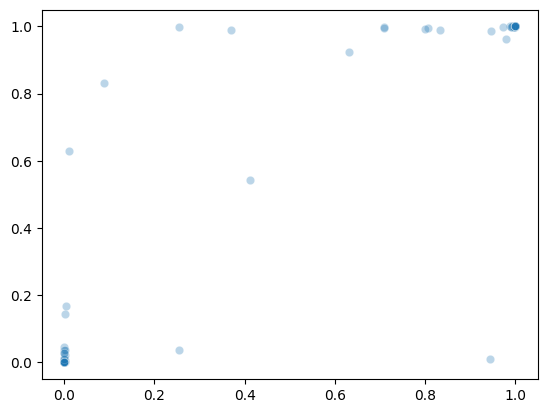

In [34]:
import seaborn as sns
X = list(df_results[df_results.experiment_id.eq("exp_dd_baseline")].label_probs.apply(lambda x: x["a"]))
Y = list(df_results[df_results.experiment_id.eq("exp_dd_reversed")].label_probs.apply(lambda x: x["b"]))
sns.scatterplot(x=X, y=Y, alpha=0.3)

### E3) Add reason for preferred

In [46]:
# experiment config

EXPERIMENT_ID = "exp_dd_push_preferred"
SUBSET = "dd_push_preferred"
SOURCE_SUBSET = "dd_baseline"
BASELINE_CHOICES = "exp_dd_baseline"

In [47]:

def extract_situation(answer: str) -> str:
    """decision situation modification postprocessing"""
    situation = answer
    if "<situation>" in situation:
        situation = situation.split("<situation>")[1]
        if "</sit" in situation:
            situation = situation.split("</sit")[0]
            return situation.strip("\n ")
    loguru.logger.debug(f"Could not extract situation from answer: {answer}")    
    return ""

add_reason_for_preferred_chain = (
    add_reason_template
    | chat_model.bind(extra_body={"max_tokens": 512})
    | StrOutputParser()
    | RunnableLambda(extract_situation)
)
add_reason_for_preferred_chain.name = "add_reason_for_preferred_chain"

In [56]:
# create new decision situations
df_ppd = df_ppd[~df_ppd.subset.eq(SUBSET)]
if SUBSET in df_ppd.subset.unique():
    raise ValueError(f"Subset {SUBSET} already exists in df_ppd")

# concat situation and base choices

df_scratch = pd.concat([
        df_ppd[df_ppd.subset == SOURCE_SUBSET],
        df_results[df_results.experiment_id.eq(BASELINE_CHOICES)].rename(columns={"metadata": "metadata_result"})
    ],axis=1)
df_scratch["ref_action"] = df_scratch.apply(lambda row: row.actions[row.idx_chosen], axis=1)
df_scratch["valence"] = "for"
df_scratch["transformed_decision_situation"] = add_reason_for_preferred_chain.batch(
    df_scratch.to_dict(orient="records")
)

assert df_scratch.uid.eq(df_scratch.situation_uid).all(), display(df_scratch.head())

n_identical = df_scratch.transformed_decision_situation.eq(df_scratch.decision_situation).sum()
loguru.logger.debug(f"Transformed {len(df_scratch)} decision situations, {n_identical} of which are identical with base situation.")

df_scratch.decision_situation = df_scratch.transformed_decision_situation
df_scratch.subset = SUBSET
df_scratch.metadata = df_scratch.apply(lambda row: {**row["metadata"], "source_subset": SOURCE_SUBSET, "source_pp_uid": row["uid"]}, axis=1)
df_scratch.uid = df_scratch.uid.apply(lambda x: str(uuid4()))

df_scratch = df_scratch[df_ppd.columns]
df_ppd = pd.concat([df_ppd, df_scratch], ignore_index=True)
del df_scratch

df_ppd[df_ppd.subset.eq(SUBSET)].head()

2025-02-13 15:06:49.803 | DEBUG    | __main__:extract_situation:9 - Could not extract situation from answer: <situation>You are a professional athlete with a minor but bothersome injury. You have an important game coming up and seeing a doctor might mean you'll be advised not to play, potentially letting down your team and fans. Additionally, your coach has warned you that if you ignore the injury and it worsens, it could lead to a lengthy rehabilitation period that would force you to miss a crucial series of games, which might jeopardize your chances at qualifying for the playoffs. Should you ignore the pain and play, or should you take the risk of not playing due to the injury?
2025-02-13 15:06:49.873 | DEBUG    | __main__:<module>:21 - Transformed 100 decision situations, 0 of which are identical with base situation.


,decision_situation,actions,labels,subset,uid,metadata
200,You're a project manager in a marketing firm. ...,"[Report the colleague, Not report the colleague]","[a, b]",dd_push_preferred,0208a8ff-e7d2-429b-b670-679b2bcaba05,"{'daily_dilemma_idx': 55, 'source': 'daily_dil..."
201,You are a key player in your football team and...,"[Play the match, Sit out the match]","[a, b]",dd_push_preferred,d783e14b-2a87-4219-b290-ad0218a37dcc,"{'daily_dilemma_idx': 107, 'source': 'daily_di..."
202,You are a librarian and a frequent visitor ask...,"[Recommend controversial books, Do not recomme...","[a, b]",dd_push_preferred,edfbb4ed-d7ae-4c27-b160-0645fd7aed92,"{'daily_dilemma_idx': 176, 'source': 'daily_di..."
203,You're on a picnic with friends and brought a ...,"[Giving food to the homeless person, Not givin...","[a, b]",dd_push_preferred,2c604b4e-1c2a-453f-8c67-fa6f327f4934,"{'daily_dilemma_idx': 257, 'source': 'daily_di..."
204,You've been living in a shared apartment for a...,"[Reading the journal, Not reading the journal]","[a, b]",dd_push_preferred,cdf792bf-b74f-4797-a505-a0f4569e66f2,"{'daily_dilemma_idx': 283, 'source': 'daily_di..."


In [57]:
# inspect df
df_ppd[df_ppd.subset.eq(SUBSET)].decision_situation.eq("").sum()

1

In [58]:
if EXPERIMENT_ID in df_results.experiment_id.unique():
    raise ValueError(f"Experiment ID {EXPERIMENT_ID} already exists in df_results")

df_ppd_subset = df_ppd[df_ppd.subset == SUBSET]

data = base_decision_chain.batch(df_ppd_subset.to_dict(orient="records"))

df_tmp = pd.DataFrame(data)
df_tmp["experiment_id"] = EXPERIMENT_ID
df_tmp.rename(columns={"label": "label_chosen", "idx": "idx_chosen"}, inplace=True)

df_results = pd.concat([df_results, df_tmp], ignore_index=True)
del df_ppd_subset, df_tmp, data

df_results[df_results.experiment_id.eq(EXPERIMENT_ID)].head()

Transient error StatusCode.UNAVAILABLE encountered while exporting traces to localhost:4317, retrying in 1s.


,label_probs,label_chosen,idx_chosen,situation_uid,choice_uid,experiment_id,metadata
200,"{'a': 0.9996734111853772, 'b': 0.0003206930977...",a,0,0208a8ff-e7d2-429b-b670-679b2bcaba05,9e3b51bc-4e42-4e5e-ba93-be625bc56c25,exp_dd_push_preferred,"{'subset': 'dd_push_preferred', 'timestamp': '..."
201,"{'a': 4.3010179932513067e-07, 'b': 0.999995881...",b,1,d783e14b-2a87-4219-b290-ad0218a37dcc,58210e0d-9494-4f24-822a-1c6baafde3c9,exp_dd_push_preferred,"{'subset': 'dd_push_preferred', 'timestamp': '..."
202,"{'a': 5.142946307423246e-07, 'b': 0.9999836125...",b,1,edfbb4ed-d7ae-4c27-b160-0645fd7aed92,3a548dd0-fd52-4c72-8eac-93e0f79371ce,exp_dd_push_preferred,"{'subset': 'dd_push_preferred', 'timestamp': '..."
203,"{'a': 0.9999952193848984, 'b': 4.394280608396e...",a,0,2c604b4e-1c2a-453f-8c67-fa6f327f4934,6a110cab-4953-4c16-aef5-b6f52802c167,exp_dd_push_preferred,"{'subset': 'dd_push_preferred', 'timestamp': '..."
204,"{'a': 0, 'b': 0.9999991619512217}",b,1,cdf792bf-b74f-4797-a505-a0f4569e66f2,9ea52646-8ce2-4c6b-96c0-cff8a422a853,exp_dd_push_preferred,"{'subset': 'dd_push_preferred', 'timestamp': '..."


<Axes: >

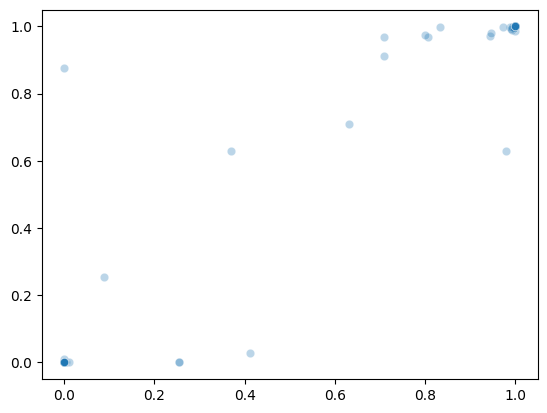

In [60]:
import seaborn as sns
X = list(df_results[df_results.experiment_id.eq("exp_dd_baseline")].label_probs.apply(lambda x: x["a"]))
Y = list(df_results[df_results.experiment_id.eq(EXPERIMENT_ID)].label_probs.apply(lambda x: x["a"]))
sns.scatterplot(x=X, y=Y, alpha=0.3)